
# SQUID V-$\Phi$ Calibration Analysis

This notebook provides a complete and documented workflow for analysing SQUID V-$\Phi$ calibration measurements using the `Fitter` class from `WP_calib.py`.

The analysis pipeline performs:

1. Loading HDF5 acquisitions
2. Detecting monitor signal periods
3. Selecting isolated triangular-drive periods
4. Detecting SQUID output crossings
5. Computing the transfer function slope
6. Estimating the conversion factor in V/$\Phi_0$
7. Studying temperature dependence

---

## Expected HDF5 Structure

Each acquisition group should contain:

| Dataset | Description |
|---|---|
| `Time` | Time axis [s] |
| `Flux` | Triangular flux-drive voltage |
| `Volt` | SQUID output voltage |

Optional attributes:
- `T_coldplate_mK`


In [1]:

# Standard imports

import sys
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from scipy.stats import linregress

# Add module path
sys.path.append(r"/home/bausciadaq/BAWSHA/src/process/VPhi")

# Import analysis class
from WP_calib import Fitter
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Global matplotlib settings
# ------------------------------------------------------------

plt.rcParams.update({

    # Figure
    "figure.figsize": (8, 6),
    "figure.dpi": 120,

    # Fonts
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,

    # Axes
    "axes.linewidth": 1.2,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Ticks
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    # Lines
    "lines.linewidth": 2,
    "lines.markersize": 7,

    # Legend
    "legend.frameon": True,

    # Savefig
    "savefig.bbox": "tight"
})



# Load Data File

Set the path to the HDF5 file containing the V-$\Phi$ scans.


In [ ]:

folder_path = r"/home/bausciadaq/Run6/DAQ/TempScans/"

# Example files
# file = folder_path + "Vphi_cooldown_highT_WP.hdf5"
#file = folder_path + "Vphi_quadris_correct_cooldown_highT_WP.hdf5"
file = folder_path + "Vphi_ch3_cooldown_highT_WP.hdf5"
file = "/home/bausciadaq/Run6/Squids_WP/Vphi_CH4_12052026.CSV"

fit = Fitter(data_path=file)

print(f"Loaded file: {fit.file_path}")


Loaded file: /home/bausciadaq/Run6/Squids_WP/Vphi_CH4_12052026.CSV



# Single-Acquisition Demonstration

This section demonstrates the complete analysis chain on a single acquisition.


In [3]:

with h5.File(fit.file_path, "r") as f:

    groups = list(f.keys())

    print(f"Number of acquisitions: {len(groups)}")

    first_group = groups[0]

    print(f"Using acquisition: {first_group}")

    data = f[first_group]

    fit.time    = data["Time"][:]
    fit.monitor = data["Flux"][:]
    fit.squid   = data["Volt"][:]
    tempcp = data.attrs["T_coldplate_mK"]

print(f"Cold plate temperature = {tempcp:.1f} mK")


OSError: Unable to synchronously open file (file signature not found)

['acq_0000_2026-06-04_16-00-34', 'acq_0001_2026-06-04_16-01-18', 'acq_0002_2026-06-04_16-02-02', 'acq_0003_2026-06-04_16-02-46', 'acq_0004_2026-06-04_16-03-29', 'acq_0005_2026-06-04_16-04-13', 'acq_0006_2026-06-04_16-04-57', 'acq_0007_2026-06-04_16-05-41', 'acq_0008_2026-06-04_16-06-24', 'acq_0009_2026-06-04_16-07-08', 'acq_0010_2026-06-04_16-07-52', 'acq_0011_2026-06-04_16-08-35', 'acq_0012_2026-06-04_16-09-19', 'acq_0013_2026-06-04_16-10-03', 'acq_0014_2026-06-04_16-10-47', 'acq_0015_2026-06-04_16-11-30', 'acq_0016_2026-06-04_16-12-14', 'acq_0017_2026-06-04_16-12-58', 'acq_0018_2026-06-04_16-13-42', 'acq_0019_2026-06-04_16-14-25', 'acq_0020_2026-06-04_16-15-09', 'acq_0021_2026-06-04_16-15-53', 'acq_0022_2026-06-04_16-16-37', 'acq_0023_2026-06-04_16-17-20', 'acq_0024_2026-06-04_16-18-04', 'acq_0025_2026-06-04_16-18-48', 'acq_0026_2026-06-04_16-19-31', 'acq_0027_2026-06-04_16-20-15', 'acq_0028_2026-06-04_16-20-59', 'acq_0029_2026-06-04_16-21-43', 'acq_0030_2026-06-04_16-22-26', 'acq_00

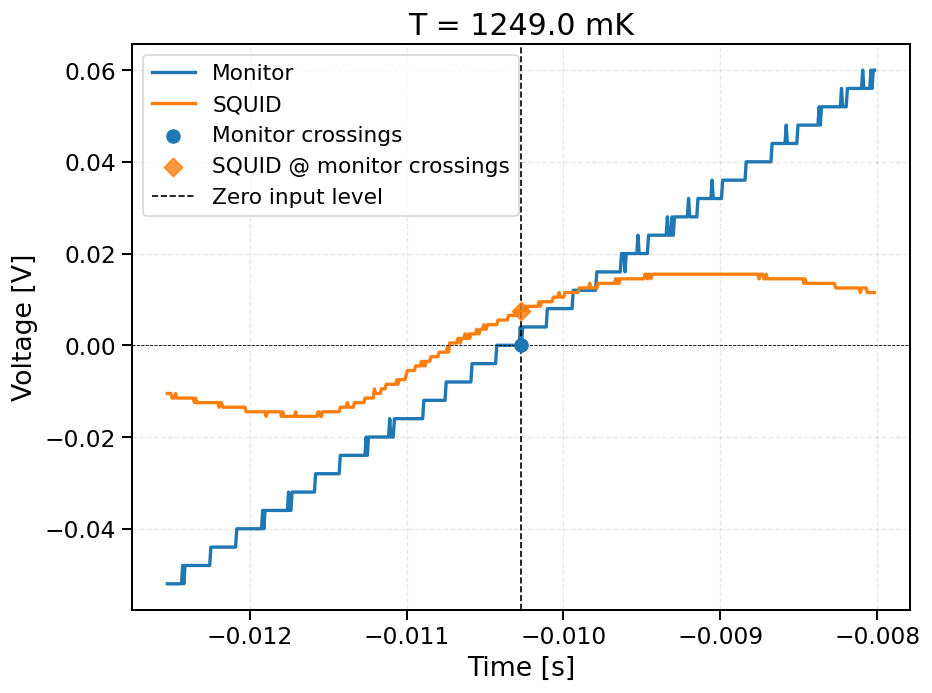

Available periods     : 2
Crossings found       : 3
Mean period [samples] : 5423
Anchor crossing : -51.367 ms
SQUID period    : 4.485 ms


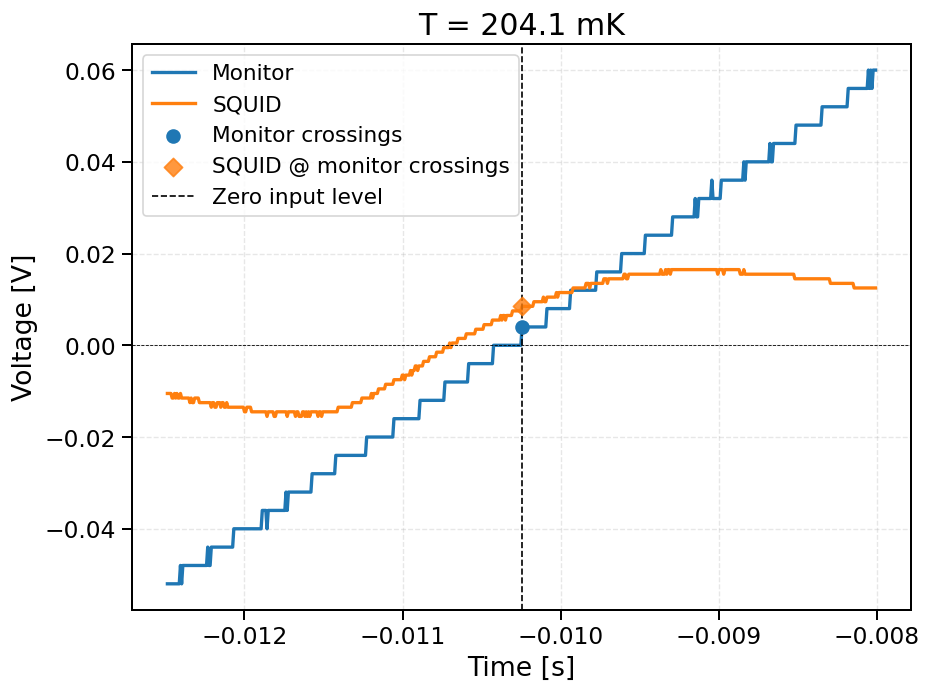

In [74]:
with h5.File(fit.file_path, "r") as f:

    groups = sorted(f.keys())
    print(groups)
    for gid, title in zip([1, -2], ["Second acquisition", "Second-to-last acquisition"]):

        group = groups[gid]
        data  = f[group]

        fit.time    = data["Time"][:]
        fit.monitor = data["Flux"][:]
        fit.squid   = data["Volt"][:]
        tempcp = data.attrs["T_coldplate_mK"]

        fit.find_monitor_crossings()
        fit.select_raise(i1=0,i2=1,i3=2,plot=False,first=True)
        fit.find_squid_crossings(min_period_ms=1.0, max_period_ms=100.0)

        cross_idx = fit.monitor_crossings[1]
        window    = fit.period_samples // 2

        i0 = max(0, cross_idx-window)
        i1 = min(len(fit.time), cross_idx+window)

        monitor_mask = (fit.monitor_crossings>=i0)&(fit.monitor_crossings<=i1)

        fig, ax = plt.subplots()

        ax.plot(fit.time[i0:i1], fit.monitor[i0:i1], lw=2, label='Monitor')
        ax.plot(fit.time[i0:i1], fit.squid[i0:i1], lw=2, label='SQUID')

        # Monitor crossing markers
        ax.scatter(fit.time[fit.monitor_crossings[monitor_mask]],
                   fit.monitor[fit.monitor_crossings[monitor_mask]],
                   marker='o', s=60, alpha=1, zorder=5,
                   label='Monitor crossings')

        # Same times projected onto SQUID curve
        ax.scatter(fit.time[fit.monitor_crossings[monitor_mask]],
                   fit.squid[fit.monitor_crossings[monitor_mask]],
                   marker='D', s=60, alpha=0.8, zorder=5,
                   label='SQUID @ monitor crossings')

        ax.axhline(0, color='k', ls='--', lw=0.5)
        ax.axvline(fit.time[fit.monitor_crossings[monitor_mask]], linewidth=1, linestyle='--',  c='k', label='Zero input level')
        ax.set(xlabel="Time [s]",
               ylabel="Voltage [V]",
               title=f"T = {tempcp:.1f} mK")

        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


## Detect Monitor Crossings

The monitor signal is the triangular flux-drive waveform.

The algorithm:
- Smooths the signal
- Applies hysteresis thresholding
- Detects rising zero-crossings
- Estimates the period


In [75]:

fit.find_monitor_crossings()


Available periods     : 2
Crossings found       : 3
Mean period [samples] : 5423



## Select a Single Period

Three different windows can be selected:
- `first=True`
- `second=True`
- `third=True`

These correspond to neighboring periods around the detected crossing.


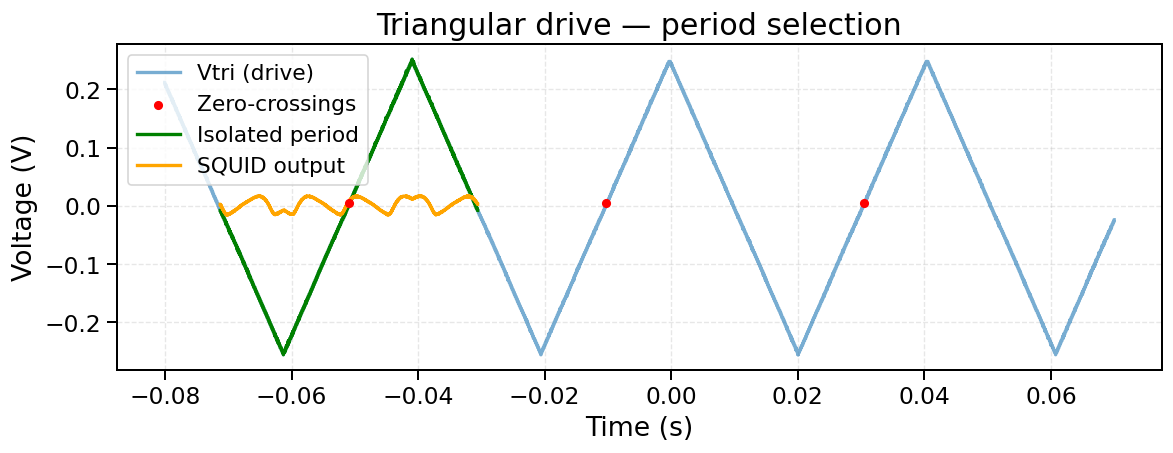

In [76]:

fit.select_raise(
    i1=0,
    i2=1,
    i3=2,
    plot=True,
    first=True
)



## Detect SQUID Crossings

The SQUID output periodicity is estimated from rising zero-crossings.


In [ ]:
fit.find_squid_crossings()

fit.plot_period()


RuntimeError: No valid SQUID period found.


## Find Working Point

The working point is defined as the zero-crossing of the SQUID output signal.


In [78]:
fit.find_vout_zero_crossing(verbose=1)


Vout zero-crossing at Vtri = -0.071163 V



## Linear Fit Around the Working Point

A local linear fit is performed around the zero-crossing region to estimate:

- transfer-function slope
- conversion factor in V/$\Phi_0$
- uncertainty


Crossing index 2712
Nsym  30
Fit window: ±30 samples around time -0.1 (total 61 pts out of 5423)

── Fit results ──────────────────────────────────────────
  Points used   : 61  (indices 2682:2742)
  Intercept     : 0.757246 V
  Period [s]    : 0.0045 
  2000 Vphi      : 0.06602982548915827 V / Phi0 ± 0.001435750601535254


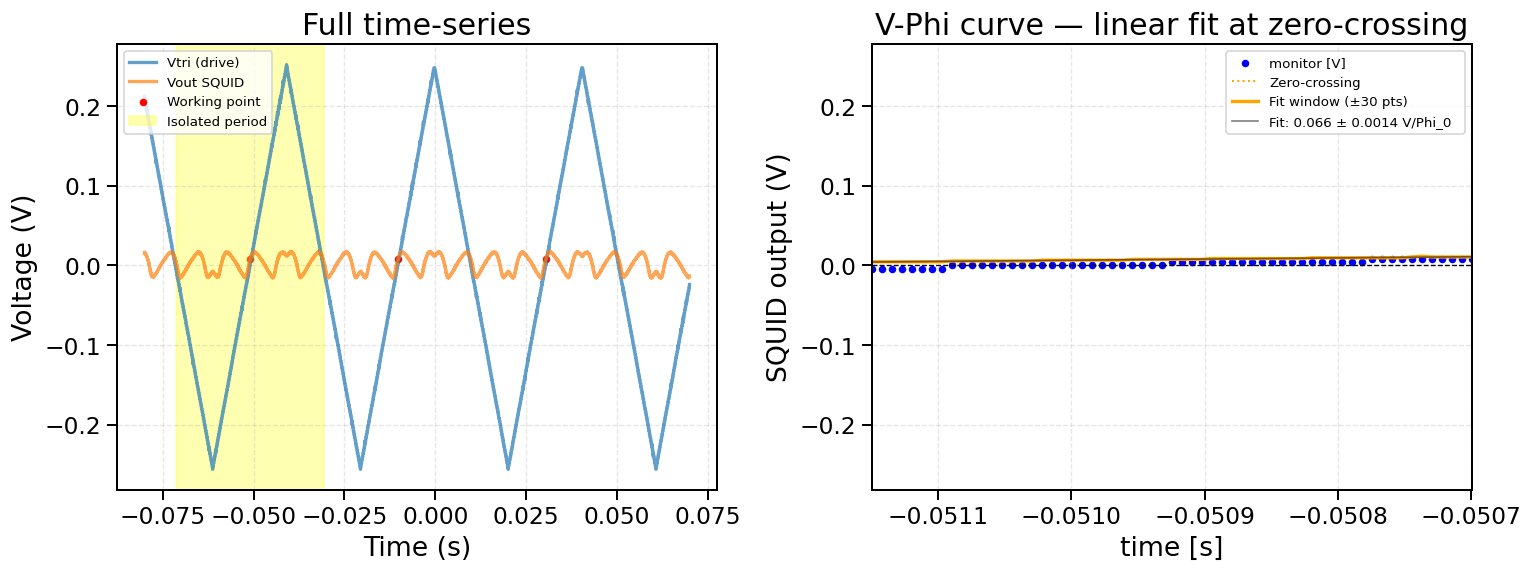

In [79]:

fit.linear_fit(
    verbose=1,
    diagnostic_plot=True,
    n_pts=30
)



# Full Temperature Scan Analysis

This section loops over all acquisitions in the HDF5 file and computes:

- average V/$\Phi_0$
- standard deviation
- average period
- temperature dependence


In [80]:
temps, Vphis, sigma_Vphis = [], [], []
Periods, sigma_Periods = [], []
Slopes, sigma_Slopes = [], []
configs = [{"first": True}, {"second": True}, {"third": True}]

with h5.File(fit.file_path, "r") as f:
    groups = list(f.keys())
    if not groups:
        raise ValueError(f"No groups found in {fit.file_path}.")
    for group in groups:
        print("-" * 70)
        print(f"Processing: {group}")
        data = f[group]
        fit.time, fit.monitor, fit.squid = data["Time"][:], data["Flux"][:], data["Volt"][:]
        fit.find_monitor_crossings()
        tempcp = data.attrs["T_coldplate_mK"]
        vphi_values, period_values, slope_values = [], [], []
        for cfg in configs:
            try:
                fit.select_raise(i1=0, i2=1, i3=2, plot=False, **cfg)
                fit.find_squid_crossings()
                #fit.plot_period()

                fit.find_vout_zero_crossing()
                fit.linear_fit(verbose=0, diagnostic_plot=False, n_pts=50)
                vphi_values.append(fit.conversion)
                period_values.append(fit.T_period)
                slope_values.append(fit.slope)
            except RuntimeError as e:
                print(f"  [SKIP] {list(cfg)[0]}: {e}")
        if not vphi_values:
            print(f"  [WARNING] all configs failed, skipping group.")
            continue
        vphi_values, period_values, slope_values = map(np.array, [vphi_values, period_values, slope_values])
        temps.append(tempcp)
        Vphis.append(np.mean(vphi_values))
        sigma_Vphis.append(np.std(vphi_values) if len(vphi_values) > 1 else np.nan)
        Periods.append(np.mean(period_values))
        sigma_Periods.append(np.std(period_values) if len(period_values) > 1 else np.nan)
        Slopes.append(np.mean(slope_values))
        sigma_Slopes.append(np.std(slope_values) if len(slope_values) > 1 else np.nan)
        print(f"  T={tempcp:.1f} mK | configs used: {len(vphi_values)}/3 | V/Phi0={np.mean(vphi_values):.4f}±{sigma_Vphis[-1]:.4f}")

temps, Vphis, sigma_Vphis = map(np.array, [temps, Vphis, sigma_Vphis])
Periods, sigma_Periods = map(np.array, [Periods, sigma_Periods])
Slopes, sigma_Slopes = map(np.array, [Slopes, sigma_Slopes])

----------------------------------------------------------------------
Processing: acq_0000_2026-06-04_16-00-34
Available periods     : 2
Crossings found       : 3
Mean period [samples] : 5421
Anchor crossing : -51.360 ms
SQUID period    : 9.030 ms
Crossing index 2709
Nsym  50
Anchor crossing : -10.687 ms
SQUID period    : 9.045 ms
Crossing index 2709
Nsym  50
Anchor crossing : 29.970 ms
SQUID period    : 9.008 ms
Crossing index 2717
Nsym  50
  T=1233.3 mK | configs used: 3/3 | V/Phi0=0.1333±0.0020
----------------------------------------------------------------------
Processing: acq_0001_2026-06-04_16-01-18
Available periods     : 2
Crossings found       : 3
Mean period [samples] : 5422
  [SKIP] first: No valid SQUID period found.
  [SKIP] second: No valid SQUID period found.
  [SKIP] third: No valid SQUID period found.
  [WARNING] all configs failed, skipping group.
----------------------------------------------------------------------
Processing: acq_0002_2026-06-04_16-02-02
Availab


# Temperature Dependence of the SQUID Period


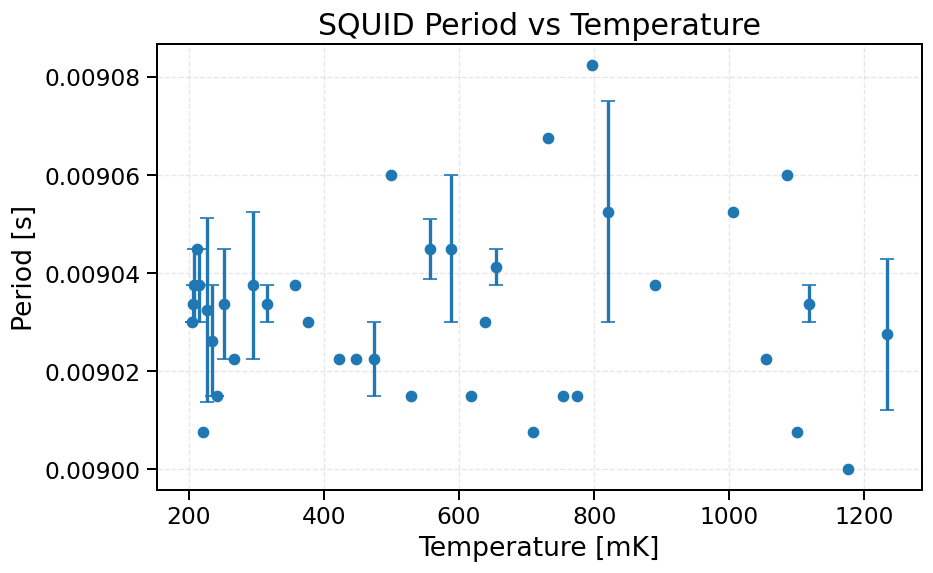

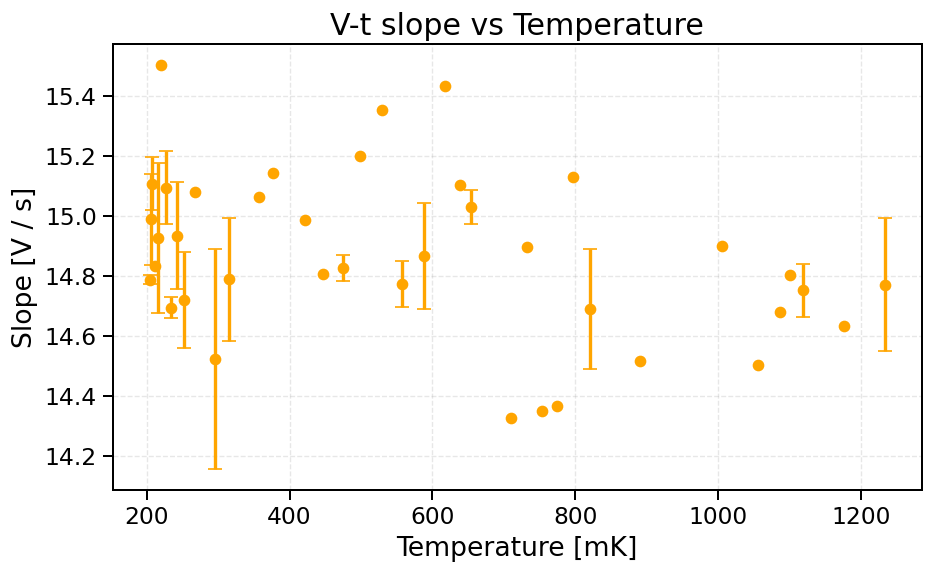

In [81]:

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(temps, Periods, yerr=sigma_Periods, linestyle='', marker='o', markersize=6, capsize=4,)
ax.set_xlabel("Temperature [mK]")
ax.set_ylabel("Period [s]")
ax.set_title("SQUID Period vs Temperature")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(temps, Slopes, yerr=sigma_Slopes, linestyle='', marker='o', c= 'orange', markersize=6, capsize=4,)
ax.set_xlabel("Temperature [mK]")
ax.set_ylabel("Slope [V / s]")
ax.set_title("V-t slope vs Temperature")

plt.tight_layout()
plt.show()


# Temperature Dependence of V/$\Phi_0$


<>:21: SyntaxWarning: invalid escape sequence '\P'
<>:21: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_480053/3039390881.py:21: SyntaxWarning: invalid escape sequence '\P'
  ax.set(xlabel='T [mK]',ylabel=r'2000 $V_{\Phi}$ [V / $\Phi_0$]',title='$V_{\Phi}$ vs T')
/home/bausciadaq/bawenv/lib64/python3.12/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/bausciadaq/bawenv/lib64/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/bausciadaq/bawenv/lib64/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/bausciadaq/bawenv/lib64/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/h

ValueError: zero-size array to reduction operation maximum which has no identity

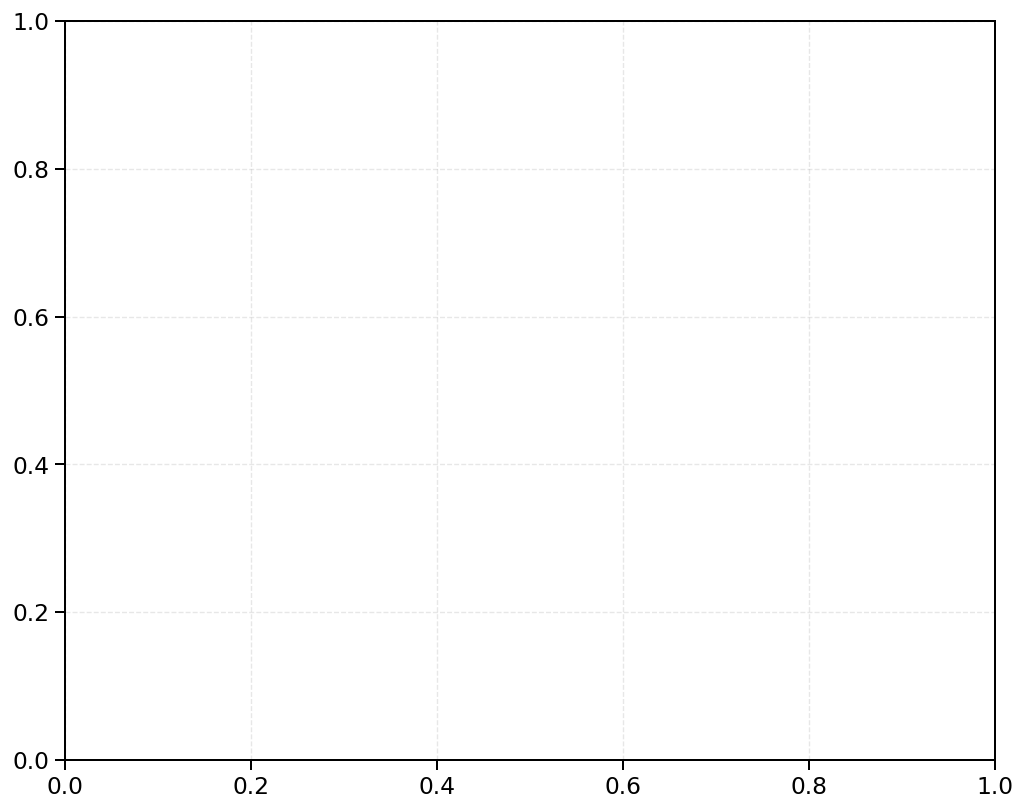

In [68]:
fig,ax=plt.subplots(figsize=(10,8))
lowmask=np.where(Vphis<0.48);highmask=np.where(Vphis>0.5)
LastHighTemp = 1400
newhighmask = np.where(temps<LastHighTemp)
highmask = np.intersect1d(highmask, newhighmask)
lowavg,lowstd=np.average(Vphis[lowmask]),np.std(Vphis[lowmask])
highavg,highstd=np.average(Vphis[highmask]),np.std(Vphis[highmask])
LastLowTemp = temps[lowmask].max()

plotmask = np.union1d(lowmask, highmask)

ax.errorbar(temps[plotmask],Vphis[plotmask],yerr=sigma_Vphis[plotmask],linestyle='',marker='o',markersize=6,capsize=4,label='Measurements')

ax.axhline(lowavg,xmax=temps[lowmask].min(),linestyle='--',linewidth=2,label=f'Low-T average = {lowavg:.3f}')
ax.fill_between(temps,lowavg-lowstd,lowavg+lowstd,alpha=0.2,label=f'Low-T ±1σ = {lowstd:.3f}')
ax.axvline(LastLowTemp, label='last low temp', linestyle='dashed', c='grey')

ax.axhline(highavg,linestyle='--',linewidth=2,label=f'High-T average = {highavg:.3f}',color='orange')
ax.fill_between(temps,highavg-highstd,highavg+highstd,alpha=0.2,label=f'High-T ±1σ = {highstd:.3f}',color='orange')

ax.set(xlabel='T [mK]',ylabel=r'2000 $V_{\Phi}$ [V / $\Phi_0$]',title='$V_{\Phi}$ vs T')
ax.legend()
plt.tight_layout();plt.show()

In [63]:
# fill csv
import pandas as pd
pd.DataFrame([[lowavg,lowstd,highavg,highstd, LastLowTemp]],columns=['VphiLowT (T<900mK)','sigma_VphilowT','VphiHighT','sigma_VphiHighT', 'LastLowTemp [mK]']).to_csv('/home/bausciadaq/Run6/DAQ/TempScans/ProcessedData/CorrectQuadrisVphis443.csv',index=False)


# try to understand if you have a factor of two beacause of 1 Mohm input impedance

Spoiler: doesnt work!


In [64]:

folder_path = r"/home/bausciadaq/Run6/DAQ/TempScans/"

# Example files
# file = folder_path + "Vphi_cooldown_highT_WP.hdf5"
file = folder_path + "Vphi_cooldown_highT_WP_averagedtraces.hdf5"

fit = Fitter(data_path=file)

print(f"Loaded file: {fit.file_path}")

with h5.File(fit.file_path, "r") as f:

    groups = list(f.keys())

    print(f"Number of acquisitions: {len(groups)}")

    first_group = groups[0]

    print(f"Using acquisition: {first_group}")

    data = f[first_group]

    fit.time    = data["Time"][:]
    fit.monitor = data["Flux"][:]
    fit.squid   = data["Volt"][:]
    tempcp = data.attrs["T_coldplate_mK"]

print(f"Cold plate temperature = {tempcp:.1f} mK")


Loaded file: /home/bausciadaq/Run6/DAQ/TempScans/Vphi_cooldown_highT_WP_averagedtraces.hdf5
Number of acquisitions: 78
Using acquisition: acq_0000_2026-05-26_16-40-33
Cold plate temperature = 1417.6 mK


Y(t) zero crossing at t = 0.069775
Y(X) zero crossing at X = 0.004
dY/dt = 203.4067823097361
dY/dX = 2.2252019148240856
First zero  = 6.977500e-02 s
Third zero  = 7.922500e-02 s
Period T    = 9.450000e-03 s


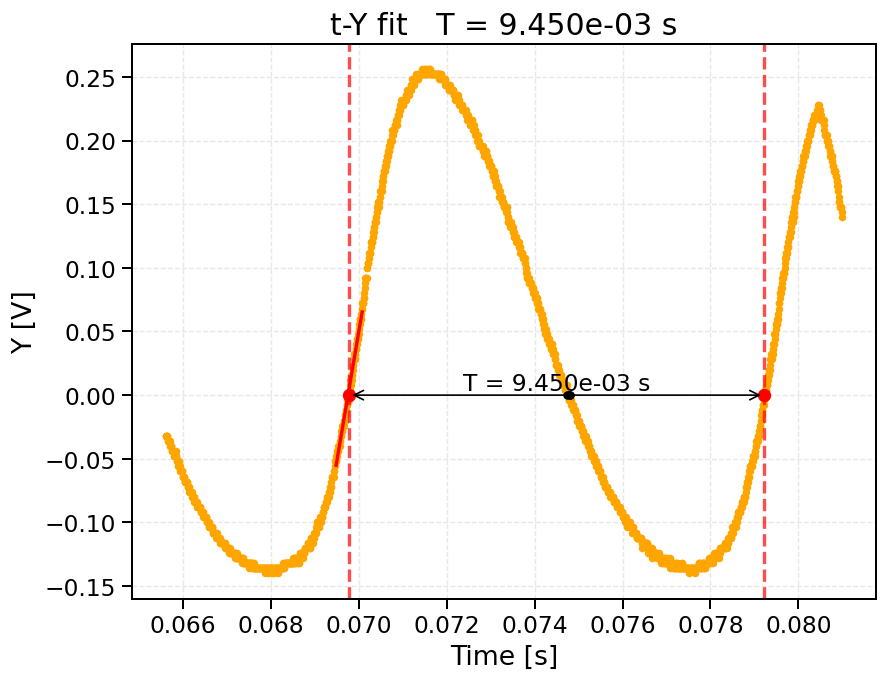

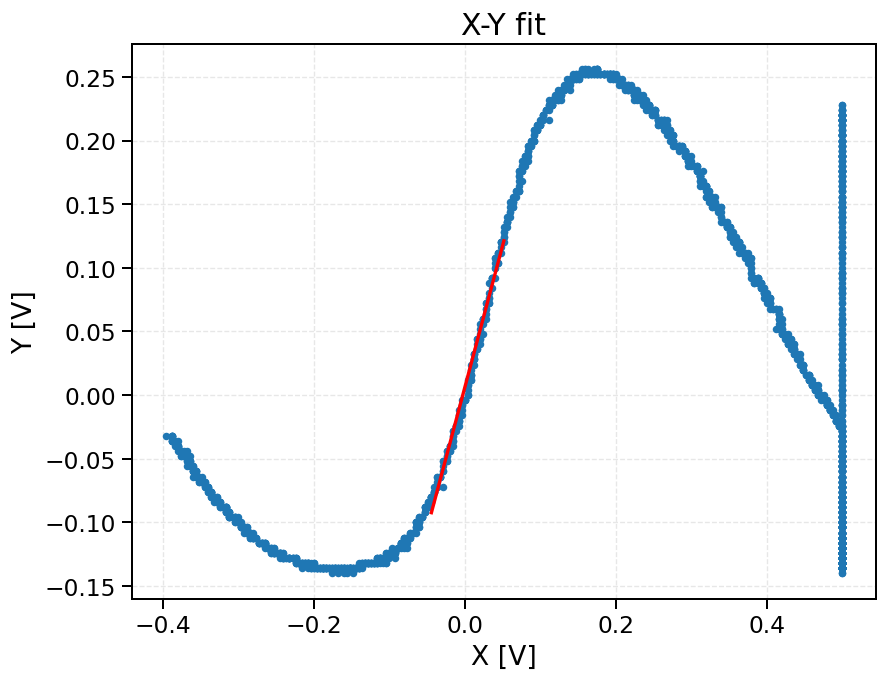

In [65]:
from scipy.stats import linregress

tinf, tsup = 0.0656, 0.081


mask = (fit.time > tinf) & (fit.time < tsup)

t = fit.time[mask]
y = fit.squid[mask]
x = fit.monitor[mask]

# Zero crossings
idx = np.where(np.diff(np.sign(y)))[0][0]

t0 = t[idx] - y[idx] * (t[idx+1] - t[idx]) / (y[idx+1] - y[idx])
x0 = x[idx] - y[idx] * (x[idx+1] - x[idx]) / (y[idx+1] - y[idx])

print("Y(t) zero crossing at t =", t0)
print("Y(X) zero crossing at X =", x0)

# Linear fits around crossings
dt, dx = 0.0003, 0.05

fit_t = linregress(t[np.abs(t - t0) < dt], y[np.abs(t - t0) < dt])
fit_x = linregress(x[np.abs(x - x0) < dx], y[np.abs(x - x0) < dx])

print("dY/dt =", fit_t.slope)
print("dY/dX =", fit_x.slope)

# All zero crossings (with interpolation)
idxs = np.where(np.diff(np.sign(y)))[0]

tzeros = t[idxs] - y[idxs] * (t[idxs+1] - t[idxs]) / (y[idxs+1] - y[idxs])

t1, t3 = tzeros[0], tzeros[7]
period_t = t3 - t1

print(f"First zero  = {t1:.6e} s")
print(f"Third zero  = {t3:.6e} s")
print(f"Period T    = {period_t:.6e} s")

# Plots
plt.figure()
plt.title(f"t-Y fit   T = {period_t:.3e} s")

plt.plot(t, y, '.', color="orange")

m = np.abs(t - t0) < dt
plt.plot(t[m], fit_t.intercept + fit_t.slope * t[m], 'r')

# mark all zero crossings
plt.plot(tzeros, np.zeros_like(tzeros), 'ko', ms=4)

# highlight first and third
plt.plot([t1, t3], [0, 0], 'ro')

# show period
plt.axvline(t1, ls='--', color='r', alpha=0.7)
plt.axvline(t3, ls='--', color='r', alpha=0.7)

plt.annotate(
    "",
    xy=(t1, 0),
    xytext=(t3, 0),
    arrowprops=dict(arrowstyle="<->")
)

plt.text(
    (t1 + t3)/2,
    0,
    f"T = {period_t:.3e} s",
    ha="center",
    va="bottom"
)

plt.xlabel("Time [s]")
plt.ylabel("Y [V]")
plt.show()

plt.figure()
plt.title("X-Y fit")
plt.plot(x, y, '.')
m = np.abs(x - x0) < dx
plt.plot(x[m], fit_x.intercept + fit_x.slope * x[m], 'r')
plt.xlabel("X [V]")
plt.ylabel("Y [V]")
plt.show()

In [9]:
X_per = x[-1] - x[0]
VphiX = fit_x.slope * X_per
VphiT = fit_t.slope * period_t
print(VphiX)
print(VphiT)

1.9937809156823807
1.922194092827006


They show same result because also in x-y fit you rescale everything by T period, which means you multiply a correct thing by a period with a factor of 2!